In [ ]:
from sklearn.datasets import make_moons,load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,VotingClassifier,BaggingClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
make_moon=make_moons(n_samples=10000,noise=0.4,random_state=42)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(make_moon[0],make_moon[1],test_size=0.2,random_state=42)


In [ ]:
y_train

array([0, 0, 1, ..., 1, 1, 0])

In [ ]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
dt=DecisionTreeClassifier(random_state=42)
sgd=SGDClassifier(random_state=42)

In [ ]:
vo_clr=VotingClassifier(
    estimators=[
        ('rf',rf),
        ('dt',dt),
        ('sgd',sgd)
    ],
    n_jobs=-1,
    voting='hard',

)

In [ ]:
vo_clr.fit(X_train,y_train)

VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('sgd', SGDClassifier(random_state=42))],
                 n_jobs=-1)

In [ ]:
for clf in (rf,dt,sgd,vo_clr):
    clf.fit(X_train,y_train)
    y_pred=clf.predict(X_test)
    print(clf.__class__.__name__,accuracy_score(y_test,y_pred))

RandomForestClassifier 0.8505
DecisionTreeClassifier 0.8145
SGDClassifier 0.841
VotingClassifier 0.8485


In [ ]:
bag_clr=BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    bootstrap=True,
    n_jobs=-1,
    oob_score=True
)

In [ ]:
bag_clr.fit(X_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1, oob_score=True)

In [ ]:
from sklearn.metrics import accuracy_score
y_pred=bag_clr.predict(X_test)
accuracy_score(y_test,y_pred)


0.876

In [ ]:
bag_clr.oob_decision_function_

array([[0.7979798 , 0.2020202 ],
       [0.97546012, 0.02453988],
       [0.15291751, 0.84708249],
       ...,
       [0.04294479, 0.95705521],
       [0.04233871, 0.95766129],
       [0.80651731, 0.19348269]])

In [ ]:
ran_for_clr=RandomForestClassifier(n_estimators=500,max_leaf_nodes=16,n_jobs=-1,bootstrap=True,max_samples=110,oob_score=True,random_state=42)
# ran_for_clr.fit(X_train,y_tra

In [ ]:
from sklearn.model_selection import cross_val_predict
ran_for_clr.fit(X_train,y_train)


RandomForestClassifier(max_leaf_nodes=16, max_samples=110, n_estimators=500,
                       n_jobs=-1, oob_score=True, random_state=42)

In [ ]:
y_pred_rf=ran_for_clr.predict(X_test)
accuracy_score(y_test,y_pred_rf)

0.8725

In [ ]:
ran_for_clr.oob_score_

0.861875

In [ ]:
ran_for_clr.feature_importances_

array([0.45771214, 0.54228786])

In [ ]:
ran_for_clr.estimator_params

('criterion',
 'max_depth',
 'min_samples_split',
 'min_samples_leaf',
 'min_weight_fraction_leaf',
 'max_features',
 'max_leaf_nodes',
 'min_impurity_decrease',
 'random_state',
 'ccp_alpha',
 'monotonic_cst')

In [ ]:
from sklearn.tree import ExtraTreeClassifier

In [ ]:
ExtraTreeClassifier()

ExtraTreeClassifier()

In [ ]:
Extra_reg=ExtraTreeClassifier(
    max_leaf_nodes=16,
    random_state=42,
    criterion='entropy',
    splitter='random',
    max_depth=None,
    min_samples_split=3,
    min_samples_leaf=5,
    # min_weight_fraction_leaf=0.0,
    max_features=4    # min_impurity_decrease=0.0


)

In [ ]:
Extra_reg.fit(X_train,y_train)

ExtraTreeClassifier(criterion='entropy', max_features=4, max_leaf_nodes=16,
                    min_samples_leaf=5, min_samples_split=3, random_state=42)

In [ ]:
ypred_extra=Extra_reg.predict(X_test)

In [ ]:
accuracy_score(ypred_extra,y_test)

0.864

In [ ]:
iris=load_iris()

In [ ]:
ran_forest_for_iris=RandomForestClassifier(n_estimators=500,n_jobs=-1,random_state=42,bootstrap=True,max_samples=100,oob_score=True)

In [ ]:
ran_forest_for_iris.fit(iris['data'],iris['target'])

RandomForestClassifier(max_samples=100, n_estimators=500, n_jobs=-1,
                       oob_score=True, random_state=42)

In [ ]:
for name, score in zip(iris['feature_names'], ran_forest_for_iris.feature_importances_):
  print(name, score)

sepal length (cm) 0.11492125766807415
sepal width (cm) 0.02606089349722216
petal length (cm) 0.439178892780289
petal width (cm) 0.41983895605441474


In [ ]:
X = iris["data"][:, 3:]   # Petal width
y = (iris["target"] == 2).astype(int)   # Iris-Virginica or not

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


# Plot feature importances


In [ ]:
# Load MNIST
mnist = fetch_openml("mnist_784", as_frame=False)

X = mnist.data
y = mnist.target

# Train Random Forest
rnd_clf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)


KeyboardInterrupt: 

In [ ]:

rnd_clf.fit(X, y)


In [ ]:
plt.imshow(
    rnd_clf.feature_importances_.reshape(28, 28),
    cmap="hot",
    interpolation="nearest"
)
plt.colorbar()
plt.axis("off")

plt.savefig("iris.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
import joblib
joblib.dump(rnd_clf, "rnd_clf.pkl")

In [ ]:
X

In [ ]:
make_moon=make_moons(n_samples=10000,noise=0.4,random_state=42)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(make_moon[0],make_moon[1],test_size=0.2,random_state=42)


In [ ]:
y_train

array([0, 0, 1, ..., 1, 1, 0])

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada_clr=AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),
    n_estimators=20,
    # algorithm=,
    learning_rate=0.5,
)

In [ ]:
ada_clr.fit(X_train,y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=20)

In [ ]:
from sklearn.metrics import accuracy_score
y_pred=ada_clr.predict(X_test)
accuracy_score(y_test,y_pred)

0.862

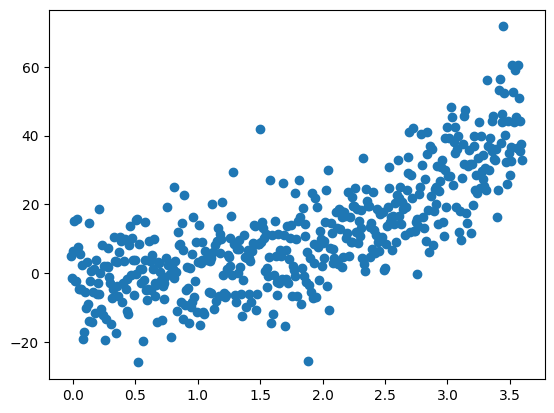

In [ ]:
np.random.seed(42)

X = np.linspace(-0.0111, 3.6, 500).reshape(-1, 1)
y = X[:, 0]**3 + np.random.randn(500) * 10

plt.scatter(X, y)
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
gradient_reg=GradientBoostingRegressor(max_depth=2,n_estimators=100,learning_rate=0.3,random_state=42)

In [ ]:
gradient_reg.fit(X,y)

GradientBoostingRegressor(learning_rate=0.3, max_depth=2, random_state=42)

In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(800, 1)

In [ ]:
cross_val_score(gradient_reg,X_train,y_train,scoring='neg_mean_squared_error',cv=5)

array([-1.13239312e+08, -1.15847100e+08, -9.58941072e+07, -1.23026242e+08,
       -1.04641394e+08])

In [ ]:
from sklearn.metrics import mean_squared_error
y_pred=gradient_reg.predict(X_test)
mean_squared_error(y_test,y_pred)

NameError: name 'gradient_reg' is not defined

In [ ]:
from sklearn.metrics import mean_absolute_error
# mean_absolute_error(y_test,y_pred)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

NameError: name 'X' is not defined

In [ ]:
gbrt=GradientBoostingRegressor(max_depth=2,n_estimators=120)

In [ ]:
gbrt.fit(X_train,y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=120)

In [ ]:
errors=[mean_squared_error(y_test,y_pred) for y_pred in gbrt.staged_predict(X_test)]

In [ ]:
best_n_estimator=np.argmin(errors)

In [ ]:
best_n_estimator

np.int64(28)

In [ ]:
grbt_best=GradientBoostingRegressor(max_depth=2,n_estimators=best_n_estimator)

In [ ]:
grbt_best.fit(X_train,y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=np.int64(28))

In [ ]:
original_mean=mean_squared_error(y_test,gbrt.predict(X_test))
actual_after_best=mean_squared_error(y_test,grbt_best.predict(X_test))

In [ ]:
original_mean

106.64840576769912

In [ ]:
actual_after_best

99.59498723966772

In [ ]:
improvement = original_mean - actual_after_best
print(improvement)

7.053418528031401


In [ ]:
improvement_percent = (
    (original_mean - actual_after_best) / original_mean
) * 100

print(improvement_percent)

6.613712110610553


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
gbrt_sq=GradientBoostingRegressor(max_depth=2,warm_start=True)

In [ ]:
min_val=float('inf')
error_going_up=0
for n_estimator in range(1,300):
    gbrt_sq.n_estimators=n_estimator
    gbrt_sq.fit(X_train,y_train)
    y_pred=gbrt_sq.predict(X_test)
    val_error=mean_squared_error(y_test,y_pred)
    if val_error<min_val:
      min_val=val_error
      error_going_up=0
    else:
      error_going_up+=1
      if error_going_up==5:
        break


In [ ]:
gbrt_sq.n_estimators_

34

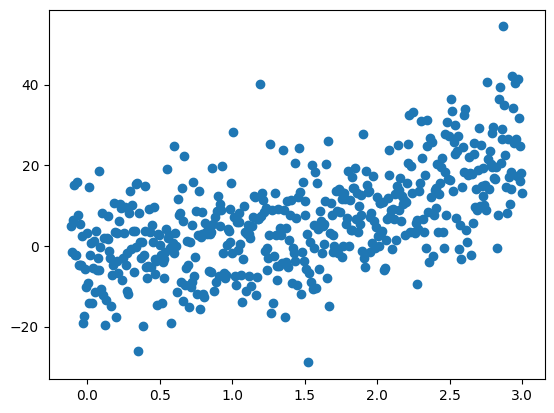

In [ ]:
np.random.seed(42)

X = np.linspace(-0.11, 3, 500).reshape(-1, 1)
y = X[:, 0]**3 + np.random.randn(500) * 10

plt.scatter(X, y)
plt.show()

In [ ]:
import xgboost


In [ ]:
xg_boost=xgboost.XGBRegressor()
xg_boost.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xg=xg_boost.predict(X_test)

In [ ]:
xg_boost_as=xgboost.XGBRegressor()


In [ ]:
from xgboost import XGBRegressor

xg_boost_as = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    early_stopping_rounds=2,
    random_state=42
)

xg_boost_as.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

[0]	validation_0-rmse:17.23153
[1]	validation_0-rmse:16.69187
[2]	validation_0-rmse:16.20183
[3]	validation_0-rmse:15.73262
[4]	validation_0-rmse:15.29801
[5]	validation_0-rmse:14.89436
[6]	validation_0-rmse:14.50253
[7]	validation_0-rmse:14.16313
[8]	validation_0-rmse:13.83847
[9]	validation_0-rmse:13.52073
[10]	validation_0-rmse:13.23806
[11]	validation_0-rmse:12.96054
[12]	validation_0-rmse:12.72415
[13]	validation_0-rmse:12.50789
[14]	validation_0-rmse:12.27302
[15]	validation_0-rmse:12.07588
[16]	validation_0-rmse:11.89108
[17]	validation_0-rmse:11.71809
[18]	validation_0-rmse:11.56441
[19]	validation_0-rmse:11.41804
[20]	validation_0-rmse:11.28426
[21]	validation_0-rmse:11.14554
[22]	validation_0-rmse:11.02644
[23]	validation_0-rmse:10.91761
[24]	validation_0-rmse:10.82443
[25]	validation_0-rmse:10.73218
[26]	validation_0-rmse:10.65061
[27]	validation_0-rmse:10.56423
[28]	validation_0-rmse:10.49456
[29]	validation_0-rmse:10.42169
[30]	validation_0-rmse:10.35919
[31]	validation_0-

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=2,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)